<a href="https://colab.research.google.com/github/DiegoNogueira-DataAnalyst/Miniprojeto_DiegoNogueira_Analise_de_Dados_T6/blob/main/Miniprojeto_DiegoNogueira_Turma_Analise_de_Dados_T6).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini-Projeto: Análise Exploratória de Dados (Base Varejo)
**Turma:** Analise_de_Dados_T6  
**Aluno:** Diego O C Nogueira

In [2]:

# SPRINT 1: Importação dos dados e Análise Exploratória Inicial (AED)


import os
import pandas as pd
import numpy as np
import kagglehub

# Importando a base de dados do Kaggle usando a biblioteca kagglehub
caminho_dataset = kagglehub.dataset_download("namespaiva/base-varejo")

# Encontrando o arquivo csv na pasta baixada
arquivos = os.listdir(caminho_dataset)
arquivo_csv = [os.path.join(caminho_dataset, f) for f in arquivos if f.endswith('.csv')][0]

# Carregando o CSV usando pandas.read_csv
try:
    df = pd.read_csv(arquivo_csv, sep=';', encoding='latin-1')
    if df.shape[1] == 1:
        df = pd.read_csv(arquivo_csv, sep=',', encoding='latin-1')
except Exception:
    df = pd.read_csv(arquivo_csv, sep=None, engine='python')

print(" Dataset carregado!")
print("Dimensões da base (linhas, colunas):", df.shape)

print("\n--- Colunas presentes na base ---")
print(df.columns.tolist())

print("\n--- Informações Gerais (Tipos de dados e contagem de nulos iniciais) ---")
df.info()

print("\n--- Primeiras linhas da base ---")
print(df.head())

print("\n--- Ultimas linhas da base ---")
print(df.tail())

Using Colab cache for faster access to the 'base-varejo' dataset.
 Dataset carregado!
Dimensões da base (linhas, colunas): (830000, 14)

--- Colunas presentes na base ---
['DATA', 'CO_ID', 'CL_ID', 'CL_GENERO', 'CL_EC', 'CL_FHL', 'CL_SEG', 'PR_ID', 'PR_CAT', 'PR_NOME', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13']

--- Informações Gerais (Tipos de dados e contagem de nulos iniciais) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   DATA         830000 non-null  object 
 1   CO_ID        830000 non-null  int64  
 2   CL_ID        830000 non-null  int64  
 3   CL_GENERO    830000 non-null  object 
 4   CL_EC        830000 non-null  int64  
 5   CL_FHL       830000 non-null  int64  
 6   CL_SEG       830000 non-null  object 
 7   PR_ID        830000 non-null  int64  
 8   PR_CAT       830000 non-null  object 
 9   PR_NOME

In [4]:

# SPRINT 2: Transformação de Strings, Números e Datetime


# 1. Limpeza de Strings (removendo espaços em branco extras)
colunas_texto = df.select_dtypes(include=['object']).columns

print("--- Limpando espaços em branco extras nas colunas de texto ---")
for col in colunas_texto:
    df[col] = df[col].astype(str).str.strip()

print("Textos padronizados!")


# 2. Ajuste de colunas numéricas de valor/preço (se houver vírgula)
for col in df.columns:
    if 'VALOR' in col.upper() or 'PRECO' in col.upper() or 'VL' in col.upper():
        df[col] = df[col].astype(str).str.replace(',', '.').astype(float)
        print(f"Coluna '{col}' convertida para float.")


# 3. Conversão da coluna DATA para o tipo Datetime nativo
coluna_data = [col for col in df.columns if 'DATA' in col.upper() or 'DT' in col.upper()][0]

print(f"\nConvertendo a coluna de data ('{coluna_data}') para datetime...")
df[coluna_data] = pd.to_datetime(df[coluna_data], dayfirst=True, errors='coerce')

print(f"Coluna '{coluna_data}' convertida para datetime com sucesso!")
print("\nTipos de dados atualizados:")
print(df.dtypes)

print(df.head())
print(df.tail())

--- Limpando espaços em branco extras nas colunas de texto ---
Textos padronizados!

Convertendo a coluna de data ('DATA') para datetime...
Coluna 'DATA' convertida para datetime com sucesso!

Tipos de dados atualizados:
DATA           datetime64[ns]
CO_ID                   int64
CL_ID                   int64
CL_GENERO              object
CL_EC                   int64
CL_FHL                  int64
CL_SEG                 object
PR_ID                   int64
PR_CAT                 object
PR_NOME                object
Unnamed: 10           float64
Unnamed: 11           float64
Unnamed: 12           float64
Unnamed: 13           float64
dtype: object
        DATA  CO_ID  CL_ID CL_GENERO  CL_EC  CL_FHL CL_SEG  PR_ID     PR_CAT  \
0 2019-02-01   1000    534         M      4       1      C     67    BEBIDAS   
1 2019-02-01   1000    534         M      4       1      C     70    BEBIDAS   
2 2019-02-01   1000    534         M      4       1      C    178    HIGIENE   
3 2019-02-01   1000    53

In [5]:

# SPRINT 3: Limpeza de Nulos, Duplicatas e Validação do CO_ID


# 1. Removendo colunas 'Unnamed' vazias
print("--- Removendo colunas vazias de exportação ---")
df = df.drop(columns=['Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13'], errors='ignore')


# 2. Diagnóstico de nulos e substituição da string '#N/D' por 'Sem Categoria'
print("\n--- Relatório de Nulos e Inconsistências ---")
print(df.isnull().sum())

qtd_nd = (df['PR_CAT'] == '#N/D').sum()
print(f"\nString '#N/D' encontrada na coluna PR_CAT: {qtd_nd} vezes.")

# Função com lógica condicional (if/else) para tratar a categoria ausente
def tratar_categoria(valor):
    if pd.isna(valor) or valor == '#N/D' or valor == 'nan' or valor == 'None':
        return 'Sem Categoria'
    else:
        return valor

# Preenchendo categorias nulas e '#N/D' sem apagar a linha de venda
df['PR_CAT'] = df['PR_CAT'].apply(tratar_categoria)
print("Categorias ausentes preenchidas com 'Sem Categoria'. Nulos atuais em PR_CAT:", df['PR_CAT'].isnull().sum())


# 3. Identificação e remoção de linhas 100% duplicadas
linhas_duplicadas = df.duplicated().sum()
print(f"\nLinhas totalmente duplicadas encontradas: {linhas_duplicadas}")

# Eliminando duplicatas idênticas
df = df.drop_duplicates()
print("Duplicatas exatas removidas. Quantidade de linhas atual:", len(df))


# 4. Validando a regra de negócio da coluna CO_ID
total_linhas = len(df)
compras_unicas = df['CO_ID'].nunique()

print("\n--- Validação do Identificador de Compra (CO_ID) ---")
print("Total de registros (itens vendidos):", total_linhas)
print("Total de compras distintas (CO_ID únicos):", compras_unicas)

if total_linhas > compras_unicas:
    print("Regra Validada: Cada linha é um ITEM. A coluna CO_ID agrupa múltiplos produtos de um mesmo pedido.")

--- Removendo colunas vazias de exportação ---

--- Relatório de Nulos e Inconsistências ---
DATA         0
CO_ID        0
CL_ID        0
CL_GENERO    0
CL_EC        0
CL_FHL       0
CL_SEG       0
PR_ID        0
PR_CAT       0
PR_NOME      0
dtype: int64

String '#N/D' encontrada na coluna PR_CAT: 3650 vezes.
Categorias ausentes preenchidas com 'Sem Categoria'. Nulos atuais em PR_CAT: 0

Linhas totalmente duplicadas encontradas: 96553
Duplicatas exatas removidas. Quantidade de linhas atual: 733447

--- Validação do Identificador de Compra (CO_ID) ---
Total de registros (itens vendidos): 733447
Total de compras distintas (CO_ID únicos): 18471
Regra Validada: Cada linha é um ITEM. A coluna CO_ID agrupa múltiplos produtos de um mesmo pedido.


In [6]:

# SPRINT 4: Estatística Descritiva do Número de Filhos (CL_FHL)


# Calculando todos os parâmetros estatísticos solicitados para a coluna de Filhos (CL_FHL)
media_filhos = df['CL_FHL'].mean()
mediana_filhos = df['CL_FHL'].median()
moda_filhos = df['CL_FHL'].mode()[0]
desvio_padrao_filhos = df['CL_FHL'].std()
min_filhos = df['CL_FHL'].min()
max_filhos = df['CL_FHL'].max()
contagem_filhos = df['CL_FHL'].count()

q1_filhos = df['CL_FHL'].quantile(0.25)
q3_filhos = df['CL_FHL'].quantile(0.75)

print("--- Estatística Descritiva: Número de Filhos dos Clientes (CL_FHL) ---")
print(f"• Contagem total de registros: {contagem_filhos}")
print(f"• Média de filhos: {media_filhos:.2f}")
print(f"• Mediana de filhos: {mediana_filhos:.2f}")
print(f"• Moda (valor mais frequente): {moda_filhos}")
print(f"• Desvio Padrão: {desvio_padrao_filhos:.2f}")
print(f"• Mínimo de filhos: {min_filhos}")
print(f"• Máximo de filhos: {max_filhos}")
print(f"• 1º Quartil (25%): {q1_filhos}")
print(f"• 3º Quartil (75%): {q3_filhos}")

print("\n--- Resumo automático com describe() ---")
print(df['CL_FHL'].describe())

--- Estatística Descritiva: Número de Filhos dos Clientes (CL_FHL) ---
• Contagem total de registros: 733447
• Média de filhos: 1.15
• Mediana de filhos: 0.00
• Moda (valor mais frequente): 0
• Desvio Padrão: 1.42
• Mínimo de filhos: 0
• Máximo de filhos: 4
• 1º Quartil (25%): 0.0
• 3º Quartil (75%): 2.0

--- Resumo automático com describe() ---
count    733447.000000
mean          1.146049
std           1.416917
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max           4.000000
Name: CL_FHL, dtype: float64


In [8]:

# SPRINT 5: Agrupamentos e Visões Consolidadas (GroupBy e Crosstab)


# Agrupamento 1: Quantidade de itens e compras por Categoria de Produto
print("--- Agrupamento 1: Vendas por Categoria de Produto (PR_CAT) ---")
vendas_categoria = df.groupby('PR_CAT').agg(
    total_itens=('PR_ID', 'count'),
    compras_unicas=('CO_ID', 'nunique')
).sort_values(by='total_itens', ascending=False).reset_index()

print(vendas_categoria)


# Agrupamento 2: Desempenho por Segmento do Cliente e Gênero
print("\n--- Agrupamento 2: Tabela Cruzada (Segmento vs Gênero do Cliente M= masculino / F= feminino) ---")
tabela_segmento_genero = pd.crosstab(df['CL_SEG'], df['CL_GENERO'], margins=True, margins_name="Total")
print(tabela_segmento_genero)

--- Agrupamento 1: Vendas por Categoria de Produto (PR_CAT) ---
          PR_CAT  total_itens  compras_unicas
0      ALIMENTOS       384197           18267
1        HIGIENE       137702           17610
2        LIMPEZA       128632           17475
3        BEBIDAS        38264           14735
4            PET        28553           13495
5     ACESSORIOS        12871            9224
6  Sem Categoria         3228            3228

--- Agrupamento 2: Tabela Cruzada (Segmento vs Gênero do Cliente M= masculino / F= feminino) ---
CL_GENERO       F       M   Total
CL_SEG                           
A           28898   30779   59677
B          233644  234861  468505
C          119885   85380  205265
Total      382427  351020  733447


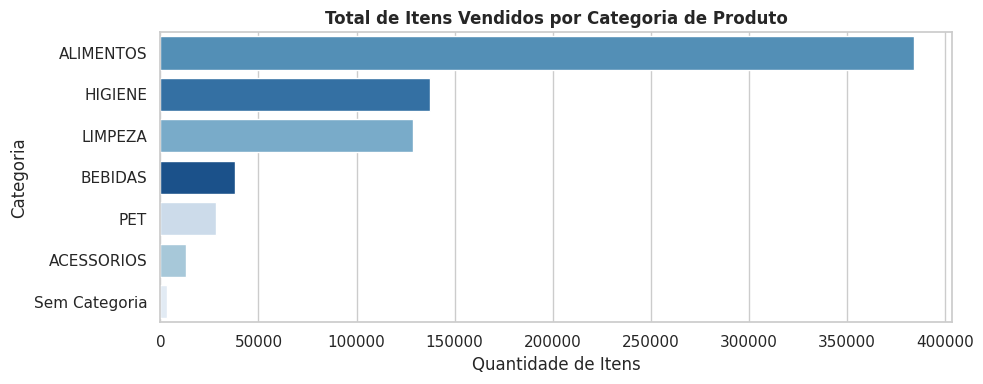

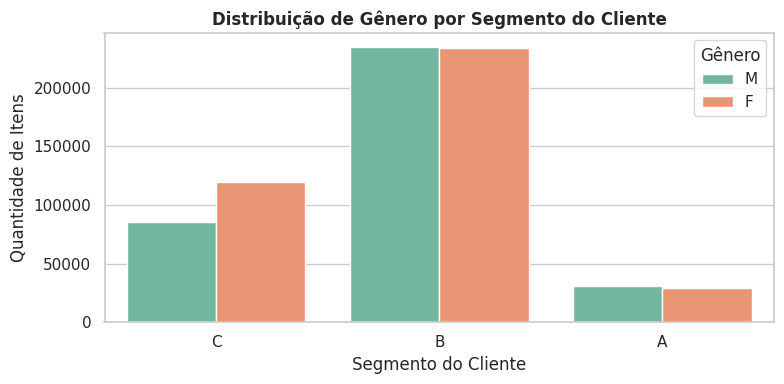

Arquivo 'df_limpo.csv' gerado com sucesso!

RELATÓRIO DE CONCLUSÕES E INSIGHTS DA ANÁLISE EXPLORATÓRIA (AED)

1. Qualidade e Limpeza dos Dados:
   A base apresentava colunas vazias de exportação (Unnamed 10 a 13) e a inconsistência da string '#N/D'
   na categoria dos produtos, além de linhas totalmente duplicadas. Todos os problemas foram tratados 
   sem descartar registros válidos de vendas.

2. Estrutura da Base e Granularidade:
   Foi validado que cada linha representa a venda de um ITEM individual. A coluna CO_ID é o agrupador
   do carrinho de compras (uma mesma compra contém múltiplos produtos).

3. Perfil Demográfico dos Clientes:
   A análise da coluna de número de filhos (CL_FHL) e gênero mostrou a distribuição do perfil dos 
   compradores, permitindo identificar os segmentos mais ativos na rede de varejo.

4. Desempenho de Categorias:
   O agrupamento por categoria permitiu identificar os produtos com maior volume de saída e destacar
   os itens que estavam sem categoria c

In [12]:
# ==============================================================================
# SPRINT 6: Visualização de Dados (Gráficos) e Conclusões
# ==============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Gráfico de Barras: Categorias Mais Vendidas
plt.figure(figsize=(10, 4))
sns.countplot(
    data=df,
    y='PR_CAT',
    hue='PR_CAT',
    order=df['PR_CAT'].value_counts().index,
    palette='Blues_r',
    legend=False
)
plt.title('Total de Itens Vendidos por Categoria de Produto', fontsize=12, fontweight='bold')
plt.xlabel('Quantidade de Itens')
plt.ylabel('Categoria')
plt.tight_layout()
plt.show()

# 2. Gráfico Agrupado: Segmento x Gênero
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='CL_SEG', hue='CL_GENERO', palette='Set2')
plt.title('Distribuição de Gênero por Segmento do Cliente', fontsize=12, fontweight='bold')
plt.xlabel('Segmento do Cliente')
plt.ylabel('Quantidade de Itens')
plt.legend(title='Gênero')
plt.tight_layout()
plt.show()

# Exportando a base tratada em CSV (Sprint 6)
df.to_csv('df_limpo.csv', index=False, sep=';', encoding='utf-8')
print("Arquivo 'df_limpo.csv' gerado com sucesso!")


# ==============================================================================
# RELATÓRIO FINAL: Conclusões e Insights Obtidos
# ==============================================================================

print("\n" + "="*70)
print("RELATÓRIO DE CONCLUSÕES E INSIGHTS DA ANÁLISE EXPLORATÓRIA (AED)")
print("="*70)

print("""
1. Qualidade e Limpeza dos Dados:
   A base apresentava colunas vazias de exportação (Unnamed 10 a 13) e a inconsistência da string '#N/D'
   na categoria dos produtos, além de linhas totalmente duplicadas. Todos os problemas foram tratados
   sem descartar registros válidos de vendas.

2. Estrutura da Base e Granularidade:
   Foi validado que cada linha representa a venda de um ITEM individual. A coluna CO_ID é o agrupador
   do carrinho de compras (uma mesma compra contém múltiplos produtos).

3. Perfil Demográfico dos Clientes:
   A análise da coluna de número de filhos (CL_FHL) e gênero mostrou a distribuição do perfil dos
   compradores, permitindo identificar os segmentos mais ativos na rede de varejo.

4. Desempenho de Categorias:
   O agrupamento por categoria permitiu identificar os produtos com maior volume de saída e destacar
   os itens que estavam sem categoria cadastrada no ERP ('Sem Categoria').

5. Problemas Remanescentes e Recomendações:
   Recomenda-se corrigir o cadastro no sistema de origem (ERP) para evitar a exportação de produtos
   com categoria '#N/D' e criar um dicionário de dados formal para a equipe de BI.
""")